# Pre-Act Agent-State Probing in the Teacher (Qwen3-32B)

**질문:** teacher 모델은 *act를 생성하기 직전*에 자신이 어떤 **agent-state**(다음에 할 행동 유형)에
있는지 내부적으로 이미 표상하고 있는가?

첫 노트북(`agent_state_separability_qwen3_32b.ipynb`)은 **act 토큰을 mean-pool** 했기 때문에 표현이
act 텍스트를 **이미 포함** → probe가 잘 맞아도 "읽어서 안다"는 거의 자명한 결과(순환적)였습니다.
여기서는 **act 텍스트를 보기 전, prefix 끝단의 hidden state**(마지막 `N_LAST` 토큰)를 써서
*예측/확정(anticipation)* 신호를 측정합니다.

**한 forward에서 3개 probe 지점**을 동시에 추출해 비교합니다 (reason→act→observe 경계 기준):

| 지점 | 위치 | 해석 |
|---|---|---|
| `pre_act`    | assistant 턴(Thought+Code) **시작 직전** prefix 마지막 N토큰 | 추론 전 순수 예측 |
| `pre_code`   | Thought는 봤고 ```py **코드 직전** | 추론 후 act 확정 |
| `during_act` | assistant 턴 전체(Thought+Code) mean-pool | (첫 노트북과 동일 baseline) |

`pre_act → pre_code → during_act` 로 갈수록 정보가 늘어나므로, **probe 정확도가 어느 지점부터
올라오는지**가 "agent-state가 *언제* 결정/표상되는가"를 말해줍니다.

## Section 1 · Setup & Config

In [1]:
import sys, os, json, ast, re, gc, warnings, logging
os.environ["CUDA_VISIBLE_DEVICES"] = "4,5"

from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

def _find_root() -> Path:
    p = Path(".").resolve()
    for _ in range(6):
        if (p / "logs" / "qa_results").exists():
            return p
        p = p.parent
    return Path("/workspace/Agent-Distillation")

ROOT = _find_root()
print("Project root:", ROOT)

# ── 설정 ────────────────────────────────────────────────────────────────────
MODEL_NAME    = "Qwen/Qwen3-32B"
DTYPE         = torch.bfloat16
DEVICE_MAP    = "auto"

INCLUDE_QA    = True
MAX_PER_STATE = 120
MAX_LEN       = 2048
SEED          = 42

N_LAST        = 8          # prefix 끝단에서 pooling 할 토큰 수
POOL          = "mean"     # "mean" | "last"
PROBE_POINTS  = ["pre_act", "pre_code", "during_act"]
PRIMARY_POINT = "pre_code"  # PCA/confusion 등 단일-지점 시각화 기준

TARGET_STATES = ["retrieve", "symbolic_math", "numeric_compute", "finalize", "compute", "inspect"]
LAYERS        = list(range(0, 65, 2))

OUT_DIR = ROOT / "outputs" / "agent_state_probe"
OUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"], "(물리 GPU 2,3)")
print("visible device count:", torch.cuda.device_count(), "| cuda:", torch.cuda.is_available())
print("probe points:", PROBE_POINTS, "| N_LAST:", N_LAST, "| pool:", POOL)

Project root: /workspace/Agent-Distillation
CUDA_VISIBLE_DEVICES: 4,5 (물리 GPU 2,3)
visible device count: 2 | cuda: True
probe points: ['pre_act', 'pre_code', 'during_act'] | N_LAST: 8 | pool: mean


## Section 2 · 로그 파싱 + act → agent-state 라벨링

첫 노트북과 동일한 파싱/라벨링. 단, 각 표본에 `step_idx`(해당 trajectory 내 act 순번)를 함께 기록해
"첫 step(추론 전 예측이 어려운 경우) vs 이후 step" 같은 세부 분석이 가능하게 합니다.

In [2]:
TEACHER_FILES = [
    ROOT / "logs/qa_results/vllm/Qwen_Qwen3-32B/math_1000_20250414_train/Qwen3-32B_temp=0.0_seed=42_type=agent_steps=5.jsonl",
    ROOT / "logs/qa_results/vllm/Qwen_Qwen3-32B/math_medium_1000_20250430_train/Qwen3-32B_temp=0.0_seed=42_type=agent_steps=5.jsonl",
]
QA_FILES = [
    ROOT / "logs/qa_results/vllm/Qwen_Qwen2.5-1.5B-Instruct/hotpotqa_500_20250422_test/Qwen2.5-1.5B-Instruct_temp=0.0_seed=42_type=agent_steps=5.jsonl",
    ROOT / "logs/qa_results/vllm/Qwen_Qwen2.5-1.5B-Instruct/musique_500_20250504_test/Qwen2.5-1.5B-Instruct_temp=0.0_seed=42_type=agent_steps=5.jsonl",
]

def load_jsonl(f):
    rows = []
    for line in open(f):
        line = line.strip()
        if not line: continue
        try: d = json.loads(line)
        except Exception: continue
        if isinstance(d, str):
            try: d = ast.literal_eval(d)
            except Exception:
                try: d = json.loads(d)
                except Exception: continue
        if isinstance(d, dict): rows.append(d)
    return rows

def get_messages(d):
    ld = d.get("log_data")
    if isinstance(ld, str):
        try: ld = ast.literal_eval(ld)
        except Exception:
            try: ld = json.loads(ld)
            except Exception: return []
    return ld.get("messages", []) if isinstance(ld, dict) else []

def role_of(m): return str(m.get("role")).split(".")[-1].lower().replace("-", "_")
def text_of(m):
    c = m.get("content")
    if isinstance(c, list): return " ".join(x.get("text","") for x in c if isinstance(x,dict))
    return str(c)

def code_of(t):
    m = re.search(r"```py(.*?)```", t, re.S) or re.search(r"Code:\s*(.*)$", t, re.S)
    return m.group(1) if m else t

def label_state(code):
    c = code.lower()
    if re.search(r"\b(retriever|web_search|wiki|document_qa|image_search|visit_webpage)\b|\bsearch\(", c): return "retrieve"
    if re.search(r"sympy|symbols\(|\bsolve\(|\bEq\(|simplify|integrate|\bdiff\(|expand\(|factor\(", code): return "symbolic_math"
    if re.search(r"\bnp\.|numpy|\bmath\.|factorial|comb\(|sqrt\(|\.evalf", code): return "numeric_compute"
    flat = re.sub(r"\s", "", code)
    if re.match(r"^final_answer\(.*\)$", flat) or (re.search(r"final_answer\(", c) and not re.search(r"\bfor\b|\bwhile\b|\bdef\b|=", code)): return "finalize"
    if re.search(r"\bfor\b|\bwhile\b|\bdef\b|range\(|append\(", code): return "compute"
    if re.search(r"\bprint\(", c): return "inspect"
    return "other"

def extract_acts(files, domain):
    out = []
    for f in files:
        if not Path(f).exists():
            print("  [skip] not found:", f); continue
        for d in load_jsonl(f):
            prefix = ""; step = 0
            for m in get_messages(d):
                if not isinstance(m, dict): continue
                r = role_of(m)
                if r == "tool_call": continue
                t = text_of(m)
                if r == "assistant":
                    out.append({"prefix": prefix, "act": t, "state": label_state(code_of(t)),
                                "domain": domain, "step_idx": step})
                    step += 1
                    prefix = prefix + "\n" + t
                else:
                    prefix = prefix + ("\n" + t if prefix else t)
    return out

acts = extract_acts(TEACHER_FILES, "math")
if INCLUDE_QA: acts += extract_acts(QA_FILES, "qa")
print("총 act 표본:", len(acts))
print("state 분포 :", dict(Counter(a["state"] for a in acts).most_common()))

총 act 표본: 7180
state 분포 : {'retrieve': 4382, 'symbolic_math': 798, 'compute': 628, 'other': 407, 'numeric_compute': 377, 'finalize': 330, 'inspect': 258}


In [3]:
by_state = defaultdict(list)
for a in acts:
    if a["state"] in TARGET_STATES:
        by_state[a["state"]].append(a)

samples = []
for st in TARGET_STATES:
    pool = by_state.get(st, [])
    if not pool:
        print(f"  [warn] state '{st}' 표본 없음 → 제외"); continue
    idx = rng.permutation(len(pool))[:MAX_PER_STATE]
    samples += [pool[i] for i in idx]
rng.shuffle(samples)
STATES = [s for s in TARGET_STATES if by_state.get(s)]
print("최종 표본:", len(samples))
print("state별 :", dict(Counter(s["state"] for s in samples).most_common()))
print("step별 :", dict(Counter(s["step_idx"] for s in samples).most_common()))

최종 표본: 720
state별 : {'numeric_compute': 120, 'inspect': 120, 'retrieve': 120, 'finalize': 120, 'compute': 120, 'symbolic_math': 120}
step별 : {0: 269, 1: 190, 2: 113, 3: 75, 4: 73}


## Section 3 · Teacher 모델 로드 (Qwen3-32B, GPU 2,3)

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
print("Loading", MODEL_NAME, "...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=DTYPE, device_map=DEVICE_MAP,
    trust_remote_code=True, output_hidden_states=True,
)
model.eval()
EMB_DEVICE = model.get_input_embeddings().weight.device
print(f"layers={model.config.num_hidden_layers}  hidden={model.config.hidden_size}  emb_device={EMB_DEVICE}")

Loading Qwen/Qwen3-32B ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 707/707 [00:07<00:00, 90.14it/s] 


layers=64  hidden=5120  emb_device=cuda:0


## Section 4 · 3개 probe 지점 표현 추출 (한 forward)

`prefix + act` 를 한 번 forward 하고, 토큰 인덱스 경계로 세 영역을 잘라 layer별 표현을 만듭니다.

- `pre_act`    : prefix 마지막 `N_LAST` 토큰 (assistant 턴 시작 직전)
- `pre_code`   : Thought 끝 ~ ```py 직전의 마지막 `N_LAST` 토큰
- `during_act` : assistant 턴(Thought+Code) 전체 mean-pool

> 경계는 `tokenizer(prefix)`, `tokenizer(prefix+thought)`, `tokenizer(prefix+act)` 의 길이로 잡습니다.
> BPE 병합 때문에 경계가 ±1 토큰 흔들릴 수 있으나 `N_LAST≥4` pooling에서는 영향이 미미합니다.
> 결과는 `outputs/`에 캐시됩니다.

In [5]:
CACHE = OUT_DIR / f"preact_reps_{'with' if INCLUDE_QA else 'no'}qa_n{MAX_PER_STATE}_L{N_LAST}_{POOL}.npz"

def _regions(prefix, act):
    pre  = tokenizer(prefix, add_special_tokens=True).input_ids
    thought = act[:act.index("```py")] if "```py" in act else act
    mid  = tokenizer(prefix + "\n" + thought, add_special_tokens=True).input_ids
    full = tokenizer(prefix + "\n" + act, add_special_tokens=True).input_ids
    n_pre, n_mid, n_full = len(pre), len(mid), len(full)
    drop = max(0, n_full - MAX_LEN)
    if drop: full = full[-MAX_LEN:]
    sh = lambda i: max(0, i - drop)
    n_pre, n_mid, n_full = sh(n_pre), sh(n_mid), len(full)
    n_mid = max(n_mid, n_pre)
    regs = {}
    a = max(0, n_pre - N_LAST);  regs["pre_act"]  = (a, max(a + 1, n_pre))
    a = max(0, n_mid - N_LAST);  regs["pre_code"] = (a, max(a + 1, n_mid))
    a = n_pre; b = n_full
    if b <= a: a = max(0, n_full - 1); b = n_full
    regs["during_act"] = (a, b)
    return full, regs

@torch.no_grad()
def rep_of(prefix, act):
    full, regs = _regions(prefix, act)
    ids = torch.tensor([full], device=EMB_DEVICE)
    hs = model(input_ids=ids, output_hidden_states=True, use_cache=False).hidden_states
    out = {}
    for pt in PROBE_POINTS:
        a, b = regs[pt]
        for L in LAYERS:
            span = hs[L][0, a:b, :]
            out[(pt, L)] = (span[-1] if POOL == "last" else span.mean(0)).float().cpu().numpy()
    return out

if CACHE.exists():
    data = np.load(CACHE, allow_pickle=True)
    X = {pt: {L: data[f"X_{pt}_{L}"] for L in LAYERS} for pt in PROBE_POINTS}
    y = data["y"]; dom = data["dom"]; step = data["step"]
    print("loaded cache:", CACHE.name)
else:
    try: from tqdm.auto import tqdm
    except Exception:
        def tqdm(x, **k): return x
    buf = {(pt, L): [] for pt in PROBE_POINTS for L in LAYERS}
    y, dom, step = [], [], []
    for s in tqdm(samples, desc="extract"):
        v = rep_of(s["prefix"], s["act"])
        for k in buf: buf[k].append(v[k])
        y.append(s["state"]); dom.append(s["domain"]); step.append(s["step_idx"])
    X = {pt: {L: np.stack(buf[(pt, L)]) for L in LAYERS} for pt in PROBE_POINTS}
    y = np.array(y); dom = np.array(dom); step = np.array(step)
    np.savez_compressed(CACHE, y=y, dom=dom, step=step,
                        **{f"X_{pt}_{L}": X[pt][L] for pt in PROBE_POINTS for L in LAYERS})
    print("saved cache:", CACHE.name)
print("표본:", len(y), "| dim:", X[PROBE_POINTS[0]][LAYERS[0]].shape[1])

loaded cache: preact_reps_withqa_n120_L8_mean.npz
표본: 720 | dim: 5120


## Section 5 · PCA 시각화

세 probe 지점을 같은 layer에서 나란히 비교 → "act를 보기 전부터 state 군집이 갈라지는가"를 눈으로 확인.

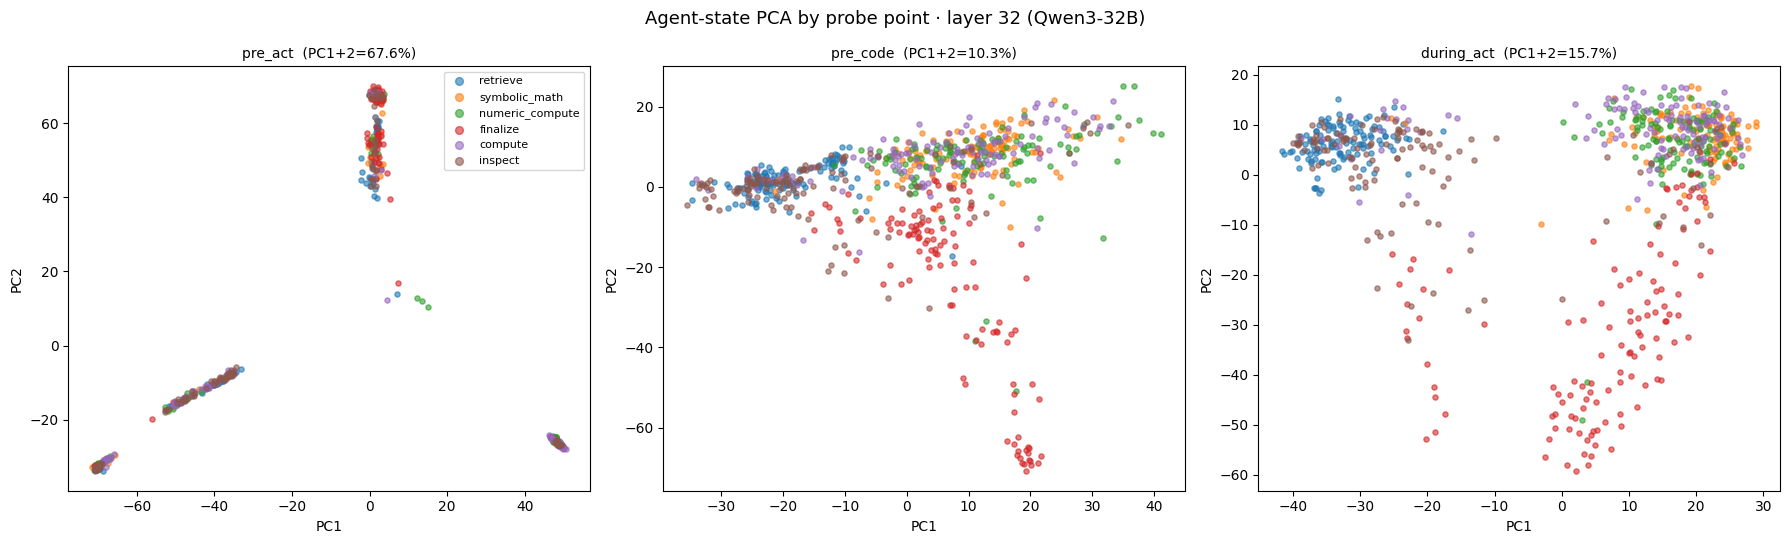

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
CMAP = {s: c for s, c in zip(STATES, matplotlib.cm.tab10.colors)}

def pca_ax(ax, mat, title):
    Z = StandardScaler().fit_transform(mat)
    p = PCA(n_components=2, random_state=SEED).fit(Z); P = p.transform(Z)
    for s in STATES:
        m = (y == s)
        ax.scatter(P[m,0], P[m,1], s=14, alpha=0.6, color=CMAP[s], label=s)
    ax.set_title(f"{title}  (PC1+2={p.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

L_SHOW = LAYERS[len(LAYERS)//2]
fig, axes = plt.subplots(1, len(PROBE_POINTS), figsize=(6*len(PROBE_POINTS), 5.5))
for ax, pt in zip(np.atleast_1d(axes), PROBE_POINTS):
    pca_ax(ax, X[pt][L_SHOW], pt)
np.atleast_1d(axes)[0].legend(markerscale=1.5, fontsize=8, loc="best")
plt.suptitle(f"Agent-state PCA by probe point · layer {L_SHOW} (Qwen3-32B)", fontsize=13)
plt.tight_layout(); plt.show()

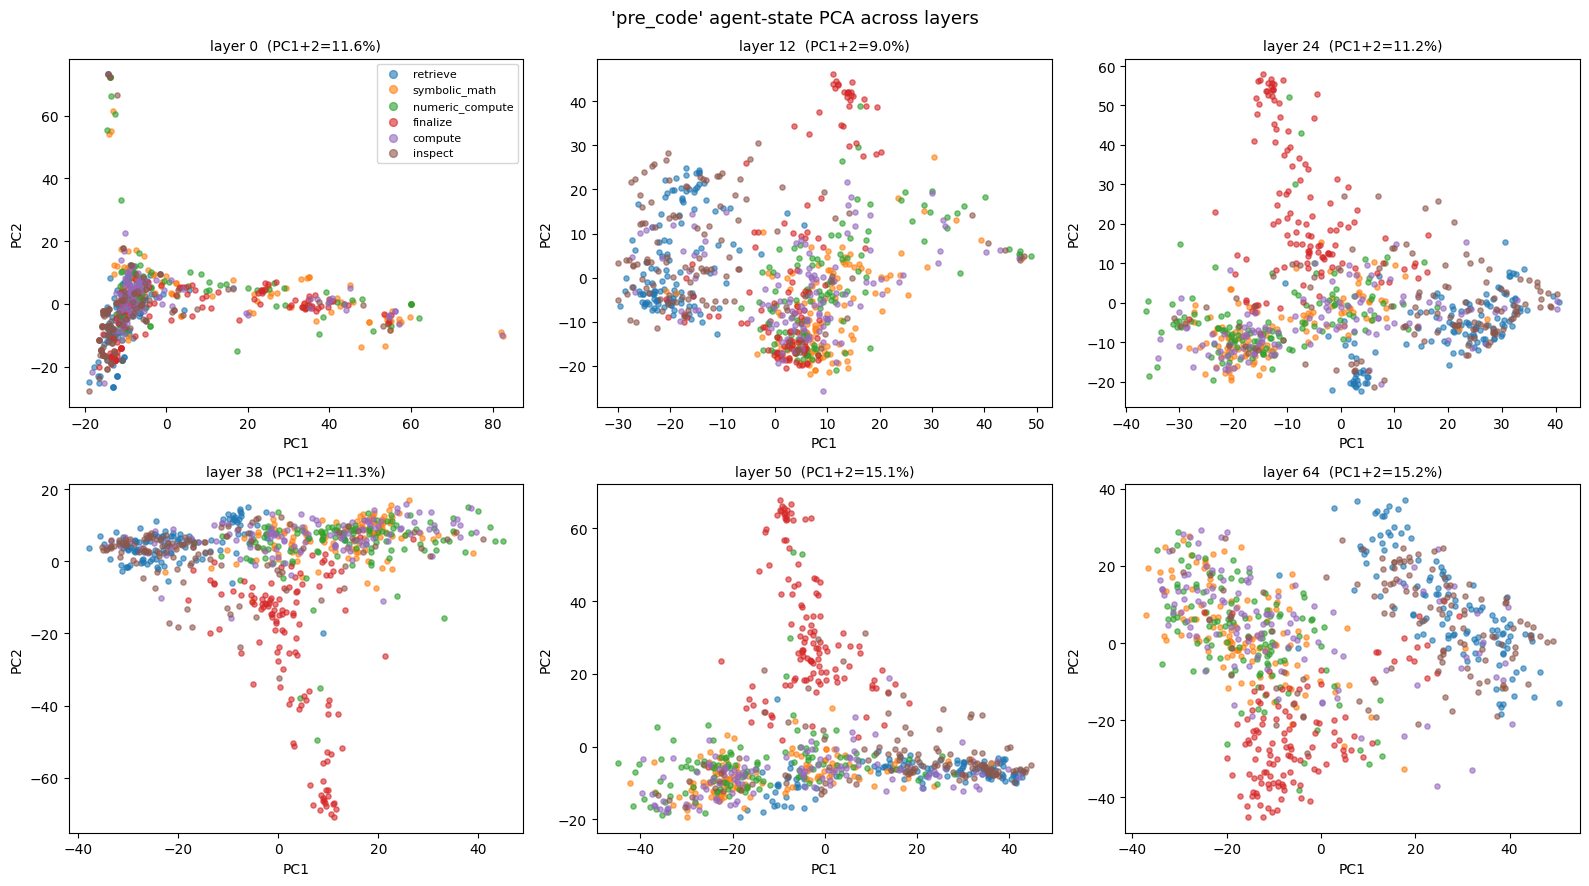

In [7]:
# PRIMARY_POINT 의 layer별 PCA grid
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
grid = [LAYERS[i] for i in np.linspace(0, len(LAYERS)-1, 6).astype(int)]
for ax, L in zip(axes.flat, grid):
    pca_ax(ax, X[PRIMARY_POINT][L], f"layer {L}")
axes.flat[0].legend(markerscale=1.5, fontsize=8, loc="best")
plt.suptitle(f"'{PRIMARY_POINT}' agent-state PCA across layers", fontsize=13)
plt.tight_layout(); plt.show()

## Section 6 · Linear probe — "언제 state를 아는가"

세 probe 지점 각각에 대해 **layer별 LogisticRegression 정확도**를 겹쳐 그립니다.
`pre_act`/`pre_code` 곡선이 chance를 크게 넘으면 → 모델은 **act를 쓰기 전에 이미 자신의 agent-state를 표상**.

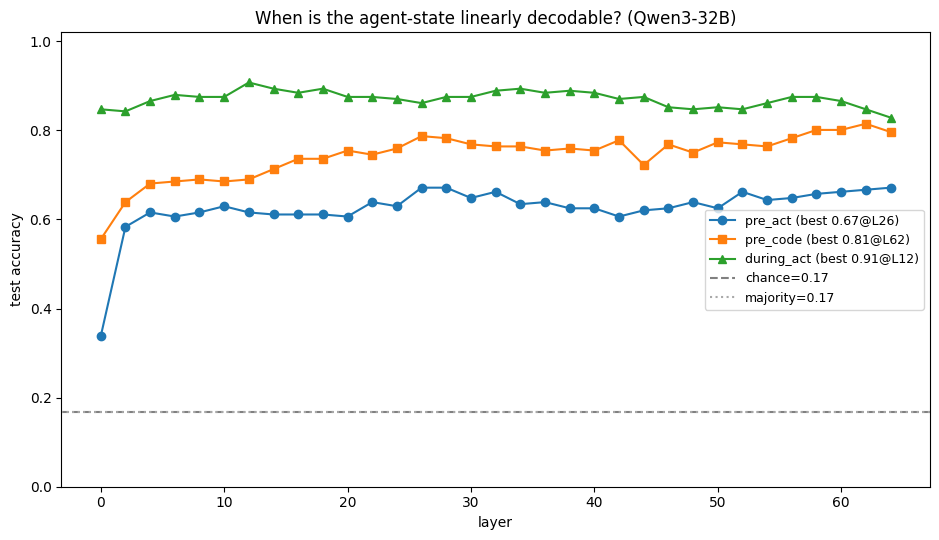

pre_act     best acc = 0.671  @ layer 26
pre_code    best acc = 0.815  @ layer 62
during_act  best acc = 0.907  @ layer 12


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline

idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.3, random_state=SEED, stratify=y)

def probe(mat):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
    clf.fit(mat[tr], y[tr]); pred = clf.predict(mat[te])
    return accuracy_score(y[te], pred), f1_score(y[te], pred, average="macro"), clf, pred

curves = {pt: [probe(X[pt][L])[0] for L in LAYERS] for pt in PROBE_POINTS}
chance = 1/len(STATES)
maj    = Counter(y[te]).most_common(1)[0][1]/len(te)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
mk = {"pre_act":"-o", "pre_code":"-s", "during_act":"-^"}
for pt in PROBE_POINTS:
    best = max(curves[pt]); bL = LAYERS[int(np.argmax(curves[pt]))]
    ax.plot(LAYERS, curves[pt], mk.get(pt,"-o"), label=f"{pt} (best {best:.2f}@L{bL})")
ax.axhline(chance, ls="--", c="gray", label=f"chance={chance:.2f}")
ax.axhline(maj,    ls=":",  c="darkgray", label=f"majority={maj:.2f}")
ax.set_xlabel("layer"); ax.set_ylabel("test accuracy"); ax.set_ylim(0,1.02)
ax.set_title("When is the agent-state linearly decodable? (Qwen3-32B)")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

for pt in PROBE_POINTS:
    print(f"{pt:11s} best acc = {max(curves[pt]):.3f}  @ layer {LAYERS[int(np.argmax(curves[pt]))]}")

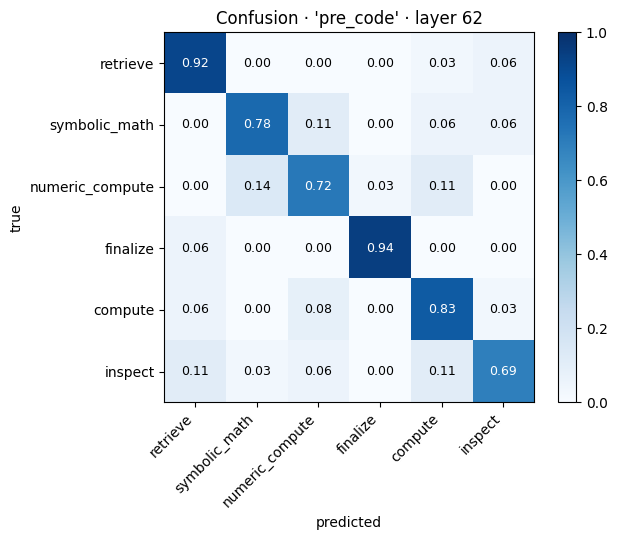

                 precision    recall  f1-score   support

       retrieve      0.805     0.917     0.857        36
  symbolic_math      0.824     0.778     0.800        36
numeric_compute      0.743     0.722     0.732        36
       finalize      0.971     0.944     0.958        36
        compute      0.732     0.833     0.779        36
        inspect      0.833     0.694     0.758        36

       accuracy                          0.815       216
      macro avg      0.818     0.815     0.814       216
   weighted avg      0.818     0.815     0.814       216



In [9]:
# PRIMARY_POINT 최적 layer confusion matrix + 리포트
bestL = LAYERS[int(np.argmax(curves[PRIMARY_POINT]))]
_, _, clf, pred = probe(X[PRIMARY_POINT][bestL])
cm = confusion_matrix(y[te], pred, labels=STATES)
cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(STATES))); ax.set_xticklabels(STATES, rotation=45, ha="right")
ax.set_yticks(range(len(STATES))); ax.set_yticklabels(STATES)
for i in range(len(STATES)):
    for j in range(len(STATES)):
        ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                color="white" if cmn[i,j]>0.5 else "black", fontsize=9)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Confusion · '{PRIMARY_POINT}' · layer {bestL}")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
print(classification_report(y[te], pred, labels=STATES, digits=3))

In [11]:
# ── Confusion matrix 심화: 오분류 분석 ─────────────────────────────────────────
# 위 셀의 PRIMARY_POINT / bestL / cm 기준. 어디로·어떤 act가 틀렸는지까지 파봅니다.
_, _, clf, pred = probe(X[PRIMARY_POINT][bestL])
true   = y[te]
proba  = clf.predict_proba(X[PRIMARY_POINT][bestL][te])   # [N_test, n_class]
classes = list(clf.classes_)                              # proba 열 순서

# samples ↔ y 정렬 확인 (동일 SEED 결정적 샘플링이라 일치해야 함)
assert [s["state"] for s in samples] == list(y), "samples/y 정렬 불일치 → Section 2부터 재실행"

# 1) true state 별 '어디로' 오분류되는가 (최다 행선지 + 전체 분포)
print(f"[{PRIMARY_POINT} · layer {bestL}] true state별 오분류 행선지")
for s in STATES:
    m_true = (true == s);            n_tot = int(m_true.sum())
    m_err  = m_true & (pred != s);   n_err = int(m_err.sum())
    if n_err == 0:
        print(f"  {s:15s}: 오분류 0/{n_tot} (recall=1.00)"); continue
    dist = [(str(k), int(v)) for k, v in Counter(pred[m_err]).most_common()]
    top, topn = dist[0]
    print(f"  {s:15s}: {n_err:2d}/{n_tot} 오분류 → 최다 '{top}' {topn}건({topn/n_err*100:.0f}%) | 전체 {dict(dist)}")

# 2) 가장 헷갈리는 (true → pred) 쌍 Top
pairs = sorted(((int(cm[i, j]), STATES[i], STATES[j])
                for i in range(len(STATES)) for j in range(len(STATES)) if i != j and cm[i, j] > 0),
               reverse=True)
print("\n가장 헷갈리는 (true → pred) 쌍 Top 6:")
for c, si, sj in pairs[:6]:
    print(f"  {si:15s} → {sj:15s} : {c}건")

# 3) 특정 state의 오분류 샘플 코드 들여다보기 (모델이 '확신'한 오답 우선)
FOCUS = "symbolic_math"     # ← 보고 싶은 true state 로 바꾸세요
SHOW  = 5
err_k = [k for k in range(len(te)) if true[k] == FOCUS and pred[k] != FOCUS]
err_k.sort(key=lambda k: proba[k, classes.index(pred[k])], reverse=True)
print(f"\n=== true='{FOCUS}' 인데 틀린 샘플 {min(SHOW, len(err_k))}/{len(err_k)}개 (오답 확신도 높은 순) ===")
for k in err_k[:SHOW]:
    orig    = samples[te[k]]
    p_wrong = proba[k, classes.index(pred[k])]      # 틀리게 고른 클래스 확률
    p_true  = proba[k, classes.index(FOCUS)]        # 정답 클래스에 준 확률
    snippet = " ".join(code_of(orig["act"]).split())[:240]
    print(f"\n pred={pred[k]:15s} p={p_wrong:.2f} (true-prob={p_true:.2f}) | domain={orig['domain']} step={orig['step_idx']}")
    print(f"   code: {snippet}")

[pre_code · layer 62] true state별 오분류 행선지
  retrieve       :  3/36 오분류 → 최다 'inspect' 2건(67%) | 전체 {'inspect': 2, 'compute': 1}
  symbolic_math  :  8/36 오분류 → 최다 'numeric_compute' 4건(50%) | 전체 {'numeric_compute': 4, 'compute': 2, 'inspect': 2}
  numeric_compute: 10/36 오분류 → 최다 'symbolic_math' 5건(50%) | 전체 {'symbolic_math': 5, 'compute': 4, 'finalize': 1}
  finalize       :  2/36 오분류 → 최다 'retrieve' 2건(100%) | 전체 {'retrieve': 2}
  compute        :  6/36 오분류 → 최다 'numeric_compute' 3건(50%) | 전체 {'numeric_compute': 3, 'retrieve': 2, 'inspect': 1}
  inspect        : 11/36 오분류 → 최다 'compute' 4건(36%) | 전체 {'compute': 4, 'retrieve': 4, 'numeric_compute': 2, 'symbolic_math': 1}

가장 헷갈리는 (true → pred) 쌍 Top 6:
  numeric_compute → symbolic_math   : 5건
  symbolic_math   → numeric_compute : 4건
  numeric_compute → compute         : 4건
  inspect         → retrieve        : 4건
  inspect         → compute         : 4건
  compute         → numeric_compute : 3건

=== true='symbolic_math' 인데 틀린 샘플 5/8개 (오답 

## Section 7 · 해석 가이드 / 메모

- **`pre_act`/`pre_code` 정확도 ≫ chance** → 모델은 *act를 생성하기 전에* 이미 자신의 agent-state를
  선형 디코딩 가능한 형태로 표상함 (= "다음 행동을 안다"). 첫 노트북의 `during_act`는 act를 읽은
  뒤라 높은 게 당연하므로, **진짜 anticipation 근거는 `pre_act`/`pre_code`** 입니다.
- **세 곡선의 간격** = 정보가 추론(Thought)을 거치며 얼마나 또렷해지는지: 보통
  `pre_act ≤ pre_code ≤ during_act`. `pre_act`만으로도 높으면 "추론 전부터 결정"되어 있다는 강한 주장.
- **layer 추이**: 보통 중후반 layer에서 피크 → 행동 의도가 깊은 층에서 형성됨.

**조정 포인트**
- `N_LAST`(끝단 토큰 수), `POOL`("mean"|"last"), `PRIMARY_POINT`
- `step_idx` 로 1-step(추론 전 예측이 어려운 첫 행동) vs 이후 step 분리 분석 가능 (`y[step>0]` 등)
- `INCLUDE_QA=False` → math-only teacher 분포만

In [10]:
del model
gc.collect(); torch.cuda.empty_cache()
print("freed.")

freed.
